# Learned Parameter Heatmaps (Square + 2 Rows)

- 上段: `M,N = (20,20)` の `V/W`
- 下段: `M,N = (200,200)` の `V/W`

すべての heatmap を正方形表示 (`aspect = DataAspect()`) します。

In [38]:
using CairoMakie
using DelimitedFiles

function detect_results_root()
    candidates = [
        joinpath(pwd(), "results", "latest_learned_parameter_heatmap"),
        joinpath(pwd(), "learned_parameter_heatmap", "results", "latest_learned_parameter_heatmap"),
    ]
    for dir in candidates
        if isdir(dir)
            return dir
        end
    end
    error("results directory not found. Please set results_root manually.")
end

function load_parameter_matrices(results_root::AbstractString, M::Integer, N::Integer)
    data_dir = joinpath(results_root, "M$(M)_N$(N)")
    v_path = joinpath(data_dir, "v_matrix.csv")
    w_path = joinpath(data_dir, "w_matrix.csv")
    if !isfile(v_path) || !isfile(w_path)
        error("CSV files not found in $(data_dir)")
    end
    v_matrix = Matrix{Float64}(readdlm(v_path, ',', Float64))
    w_matrix = Matrix{Float64}(readdlm(w_path, ',', Float64))
    return v_matrix, w_matrix
end

function plot_two_configs(results_root::AbstractString; configs = [(20, 20), (200, 200)], colormap = :RdBu)
    loaded = [(M, N, load_parameter_matrices(results_root, M, N)...) for (M, N) in configs]

    all_values = Float64[]
    for (_, _, v_matrix, w_matrix) in loaded
        append!(all_values, vec(v_matrix))
        append!(all_values, vec(w_matrix))
    end
    c = maximum(abs, all_values)
    c = c == 0 ? 1.0 : c

    fig = Figure(size = (900, 800))

    for (row, (M, N, v_matrix, w_matrix)) in enumerate(loaded)
        ax_w = Axis(
            fig[row, 1],
            title = "Learned W (M=$(M), N=$(N))",
            xlabel = "column",
            ylabel = "row",
            aspect = DataAspect(),
            yreversed = true,
        )
        hm_w = heatmap!(ax_w, w_matrix'; colormap = colormap, colorrange = (-c, c))
        Colorbar(fig[row, 2], hm_w)

        ax_v = Axis(
            fig[row, 3],
            title = "Learned V (M=$(M), N=$(N))",
            xlabel = "column",
            ylabel = "row",
            aspect = DataAspect(),
            yreversed = true,
        )
        hm_v = heatmap!(ax_v, v_matrix'; colormap = colormap, colorrange = (-c, c))
        Colorbar(fig[row, 4], hm_v)
    end

    for (r, ccol, panel_label) in [(1, 1, "A"), (2, 1, "B"), ]
        Label(
            fig[r, ccol, TopLeft()],
            panel_label,
            fontsize = 24,
            padding = (0, 0, 12, 12),
            halign = :left,
            font = :bold,
            valign = :top,
        )
    end

    return fig
end


plot_two_configs (generic function with 1 method)

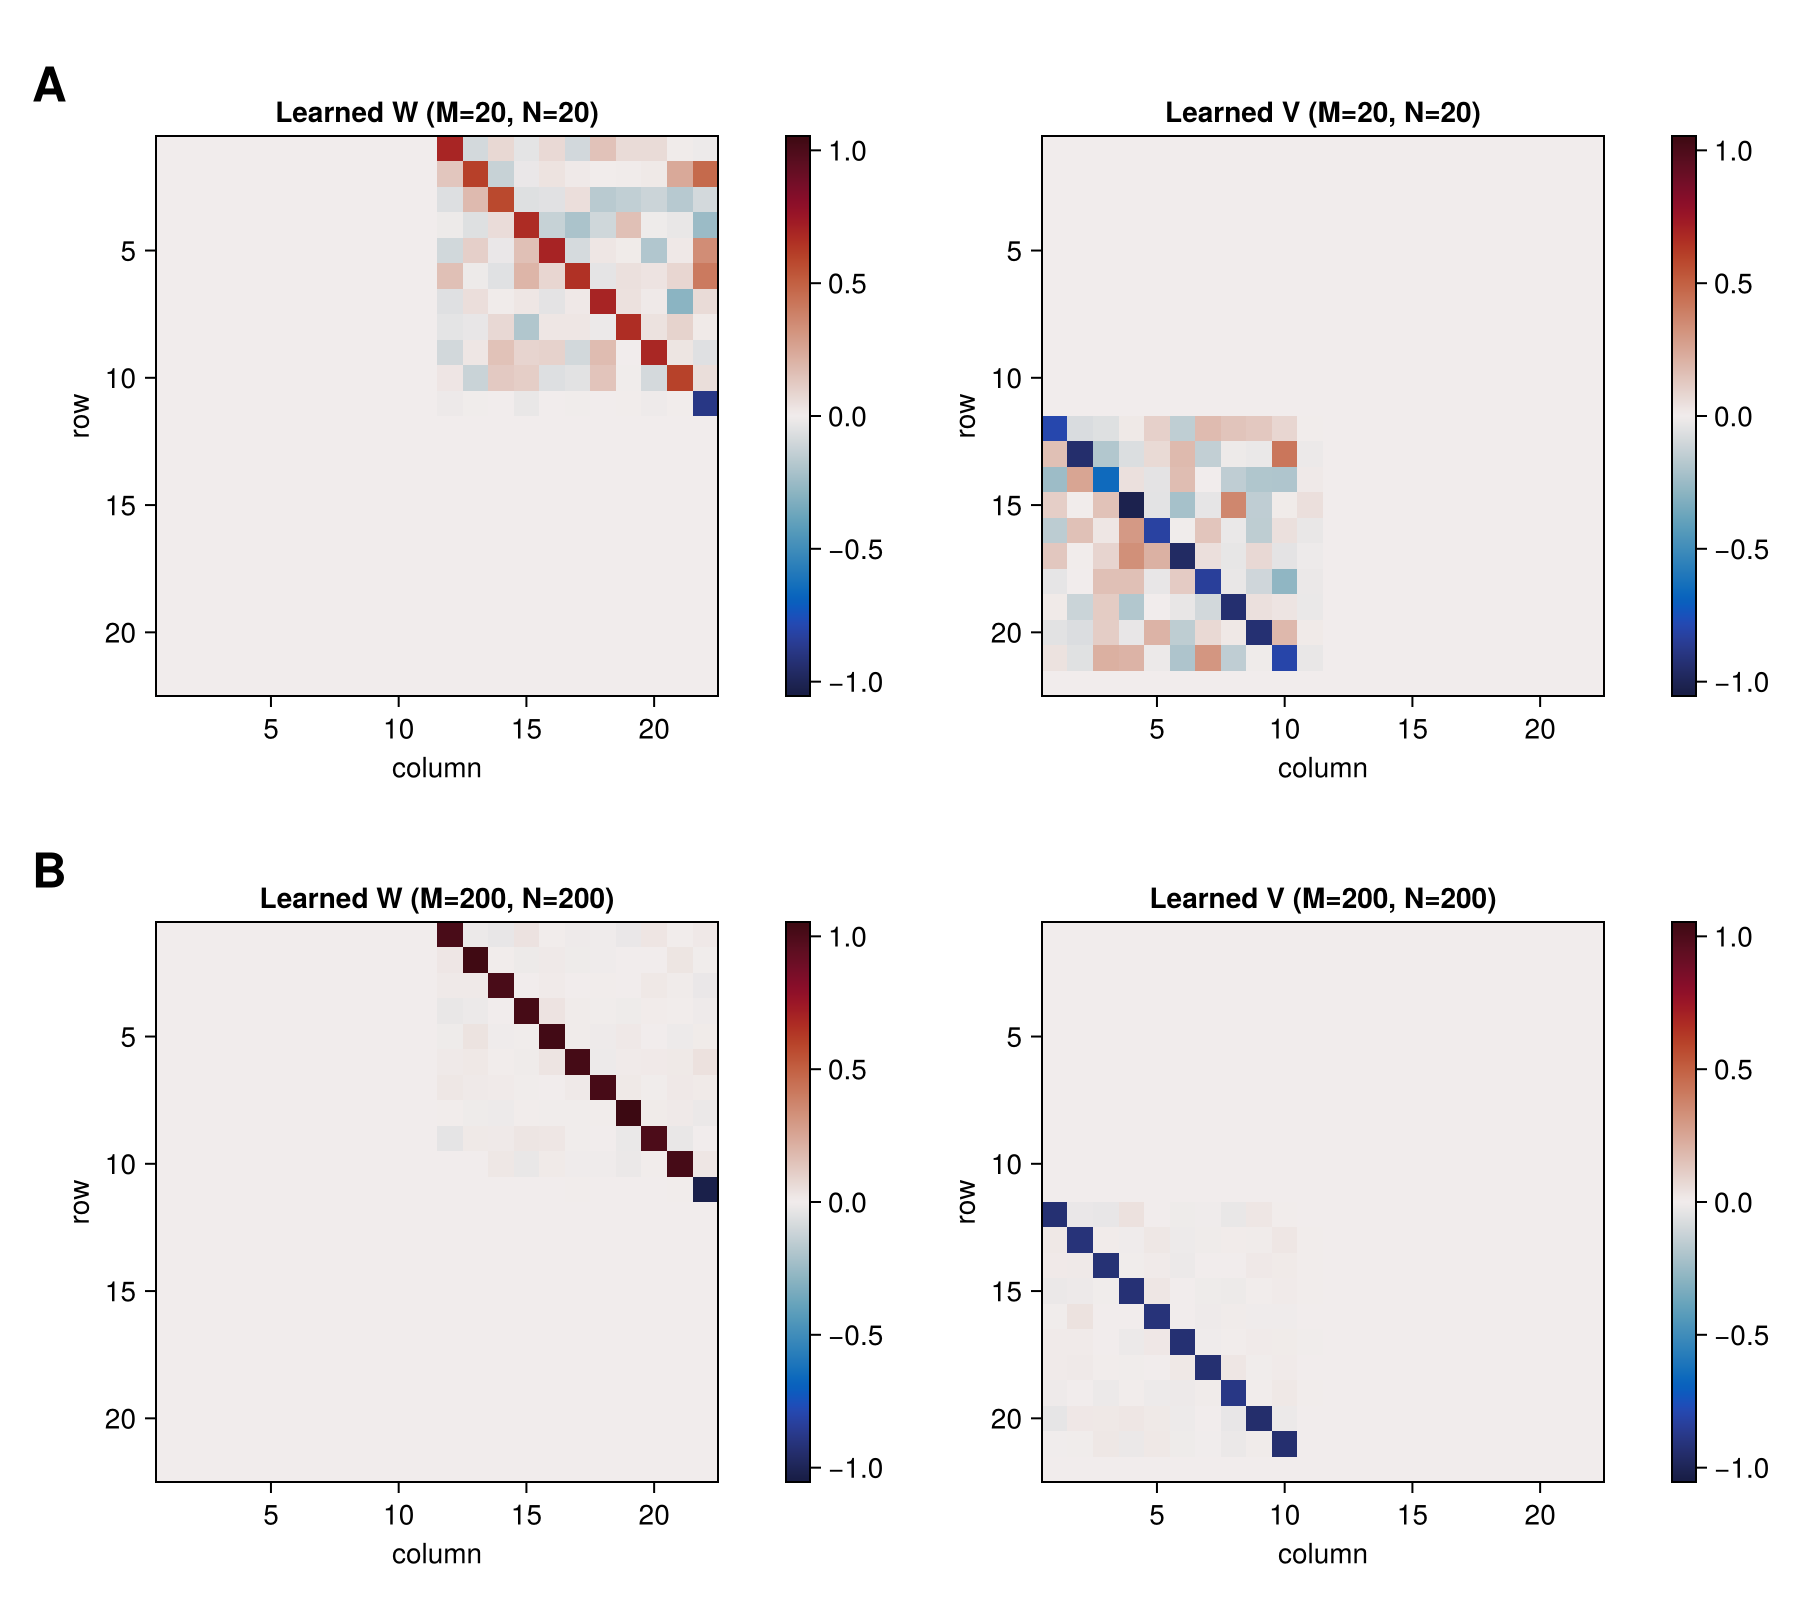

CairoMakie.Screen{PDF}


In [39]:
results_root = detect_results_root()
configs = [(20, 20), (200, 200)]

fig = plot_two_configs(results_root; configs = configs, colormap = :balance)
display(fig)

save("/home/takanami/cot_asymptotics/learned_parameter_heatmap/comparison_square_makie.pdf", fig)
